In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
rainfall_df = pd.read_csv("D:\CS 6th sem books\Summer2026\Weather_Analysis\data\proccessed\cleaned_rainfall.csv")
weather_df = pd.read_csv("D:\CS 6th sem books\Summer2026\Weather_Analysis\data\proccessed\cleaned_weather.csv")

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\New Ameen Computer\AppData\Local\Temp\ipykernel_11136\2490315319.py:1: SyntaxWarning: invalid escape sequence '\C'
  rainfall_df = pd.read_csv("D:\CS 6th sem books\Summer2026\Weather_Analysis\data\proccessed\cleaned_rainfall.csv")
C:\Users\New Ameen Computer\AppData\Local\Temp\ipykernel_11136\2490315319.py:2: SyntaxWarning: invalid escape sequence '\C'
  weather_df = pd.read_csv("D:\CS 6th sem books\Summer2026\Weather_Analysis\data\proccessed\cleaned_weather.csv")


# RAINFALL ANALYSIS VISUALIZATIONS

### National Rainfall Trend Line

✅ Trend line saved!


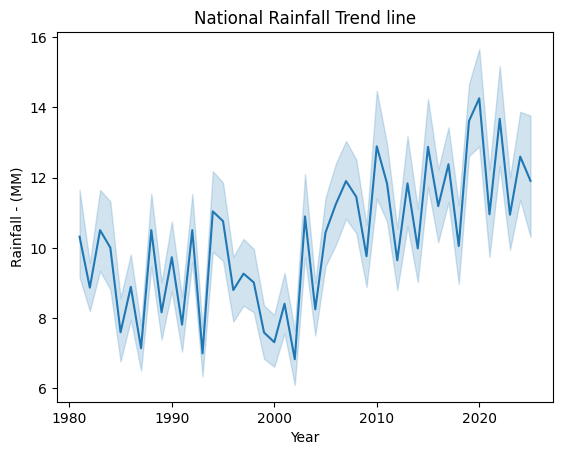

In [227]:
sns.lineplot(x="Year",y="Rainfall - (MM)",data=rainfall_df)
plt.title("National Rainfall Trend line")
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\trend_line.png',
    dpi=300,     
    bbox_inches='tight'
)
print("✅ Trend line saved!")
plt.show()
plt.close()

### Seasonal Rainfall Heatmap

In [228]:
monthly_avg = rainfall_df.groupby(['Month', 'Year'])['Rainfall - (MM)'].mean().reset_index()
monthly_avg.columns = ['Month', 'Year', 'Avg_Rainfall']
print(monthly_avg.head(20))
print(f"Shape: {monthly_avg.shape}")

    Month  Year  Avg_Rainfall
0   April  1981      6.300000
1   April  1982      5.955556
2   April  1983      6.188889
3   April  1984      7.788889
4   April  1985      5.666667
5   April  1986      6.077778
6   April  1987      5.277778
7   April  1988      4.844444
8   April  1989      4.088889
9   April  1990      5.922222
10  April  1991      9.033333
11  April  1992      8.933333
12  April  1993      5.388889
13  April  1994      9.855556
14  April  1995     17.988889
15  April  1996      6.788889
16  April  1997     12.233333
17  April  1998     10.666667
18  April  1999      3.055556
19  April  2000      3.188889
Shape: (535, 3)


In [229]:
month_mapping = {
    'January': 1, 'February': 2, 'March': 3,
    'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9,
    'October': 10, 'November': 11, 'December': 12
}

monthly_avg['Month_Num'] = monthly_avg['Month'].map(month_mapping)
monthly_avg = monthly_avg.sort_values('Month_Num')
print(monthly_avg.head(20))

       Month  Year  Avg_Rainfall  Month_Num
220  January  2023      5.644444          1
221  January  2024      3.300000          1
222  January  2025      3.000000          1
204  January  2007      2.555556          1
205  January  2008     15.377778          1
206  January  2009     12.755556          1
207  January  2010      5.055556          1
208  January  2011      3.233333          1
209  January  2012      5.455556          1
210  January  2013      3.455556          1
211  January  2014      5.755556          1
212  January  2015      5.344444          1
213  January  2016      5.600000          1
214  January  2017     16.866667          1
215  January  2018      2.366667          1
216  January  2019     13.633333          1
217  January  2020     12.377778          1
218  January  2021      3.177778          1
219  January  2022     19.022222          1
188  January  1991      7.544444          1


In [230]:
pivot_data = monthly_avg.pivot_table(
    index='Month',
    columns='Year',
    values='Avg_Rainfall'
)
print(pivot_data)
print(f"shape {pivot_data.shape}")

Year            1981       1982       1983       1984       1985       1986  \
Month                                                                         
April       6.300000   5.955556   6.188889   7.788889   5.666667   6.077778   
August     20.233333  23.566667  43.544444  40.811111  19.655556  26.333333   
December    2.188889   7.422222   2.200000   2.322222  10.300000   5.100000   
February   12.155556  12.422222   7.622222   6.866667   3.011111   8.555556   
January    12.066667   8.344444   7.422222   3.455556   6.644444   3.355556   
July       36.322222  13.822222  21.766667  23.855556  24.933333  19.733333   
June        4.688889   4.466667   5.388889   6.566667   3.622222   8.300000   
March      17.933333  13.788889   9.188889  12.366667   5.877778  13.577778   
May         4.155556   6.288889   6.311111   2.422222   4.000000   3.366667   
November    1.511111   3.355556   0.833333   1.977778   0.988889   4.300000   
October     1.622222   2.088889   1.388889   0.98888

In [231]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
pivot_data = pivot_data.reindex(month_order)
print(pivot_data)

Year            1981       1982       1983       1984       1985       1986  \
Month                                                                         
January    12.066667   8.344444   7.422222   3.455556   6.644444   3.355556   
February   12.155556  12.422222   7.622222   6.866667   3.011111   8.555556   
March      17.933333  13.788889   9.188889  12.366667   5.877778  13.577778   
April       6.300000   5.955556   6.188889   7.788889   5.666667   6.077778   
May         4.155556   6.288889   6.311111   2.422222   4.000000   3.366667   
June        4.688889   4.466667   5.388889   6.566667   3.622222   8.300000   
July       36.322222  13.822222  21.766667  23.855556  24.933333  19.733333   
August     20.233333  23.566667  43.544444  40.811111  19.655556  26.333333   
September   4.666667   4.900000  14.200000  10.688889   4.844444   6.933333   
October     1.622222   2.088889   1.388889   0.988889   1.633333   1.077778   
November    1.511111   3.355556   0.833333   1.97777

✅ Heatmap saved!


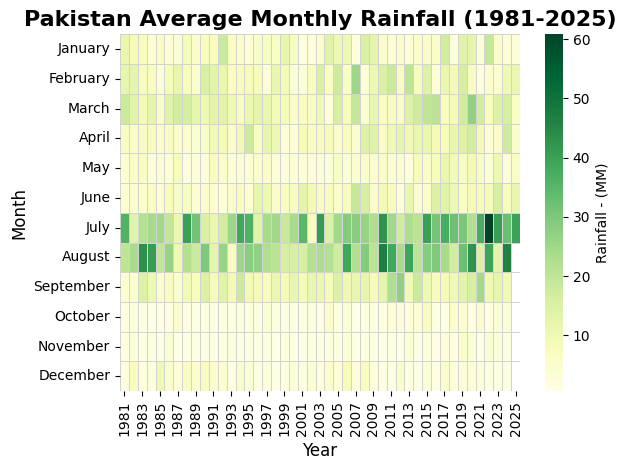

In [232]:
plt.Figure(figsize=(16,8),dpi=150)
sns.heatmap(pivot_data,
            cmap="YlGn",
            cbar_kws={'label':'Rainfall - (MM)'},
            linewidths=0.5,
            linecolor="lightgrey")
plt.title('Pakistan Average Monthly Rainfall (1981-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\seasonal_heatmap.png',
    dpi=300,     
    bbox_inches='tight'
)
print("✅ Heatmap saved!")
plt.show()
plt.close()

### Rainfall by Quarter

✅ boxplot saved!


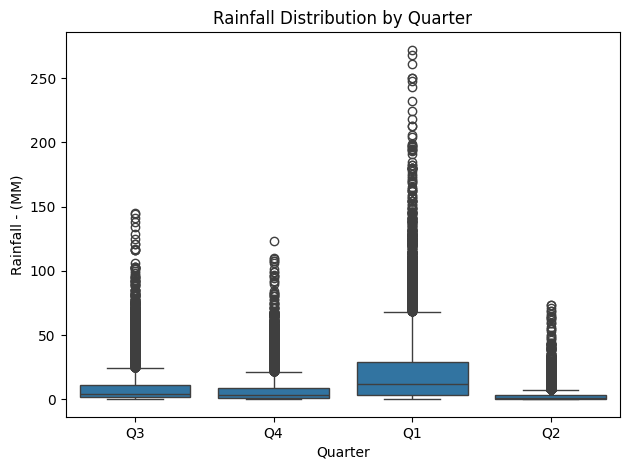

In [233]:
sns.boxplot(x="Quarter",y="Rainfall - (MM)",data=rainfall_df)
plt.title('Rainfall Distribution by Quarter')
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\rainfall_distribution.png',
    dpi=300,     
    bbox_inches='tight'
)
print("✅ boxplot saved!")
plt.show()
plt.close()

### Top & Bottom Rainfall Cities

In [234]:
averagerainfall_cities = rainfall_df.groupby("City").agg(
    Average_Rainfall = ("Rainfall - (MM)","mean")
)
print(averagerainfall_cities)

                    Average_Rainfall
City                                
Attock                     21.892212
Bahawalpur                  4.502181
Bhakkar                    11.687850
Chagai                      2.889097
Chitral Upper              16.378193
D. I. Khan                  8.244860
Dera Bugti                  5.598131
Gujranwala                 19.669782
Islamabad                  32.504673
Jamshoro                    4.292212
Jhang                       7.657944
Kachhi                      3.138318
Kambar Shahdad Kot          2.494081
Kasur                      13.260436
Kech                        2.598131
Khairpur                    3.466044
Killa Saifullah             6.633645
Kohat                      16.023053
Kohistan Upper             25.454206
Lakki Marwat               11.276636
Malir Karachi               5.213084
Mardan                     22.565109
Nowshera                   15.444860
Okara                       6.629907
Rajanpur                    5.858567
S

In [235]:
averagerainfall_cities.sort_values(by="Average_Rainfall",inplace=True)

In [236]:
topdriestcities = averagerainfall_cities.head(10)
topwettestcities = averagerainfall_cities.tail(10)
combinedCities = pd.concat([topdriestcities,topwettestcities])
combinedCities.reset_index(inplace=True)
print(combinedCities)

                  City  Average_Rainfall
0   Kambar Shahdad Kot          2.494081
1                 Kech          2.598131
2               Chagai          2.889097
3               Kachhi          3.138318
4               Washuk          3.371963
5             Khairpur          3.466044
6              Sanghar          4.013707
7               Vehari          4.145171
8             Jamshoro          4.292212
9           Bahawalpur          4.502181
10               Kasur         13.260436
11    South Waziristan         13.314642
12            Nowshera         15.444860
13               Kohat         16.023053
14       Chitral Upper         16.378193
15          Gujranwala         19.669782
16              Attock         21.892212
17              Mardan         22.565109
18      Kohistan Upper         25.454206
19           Islamabad         32.504673


✅ barchart saved!


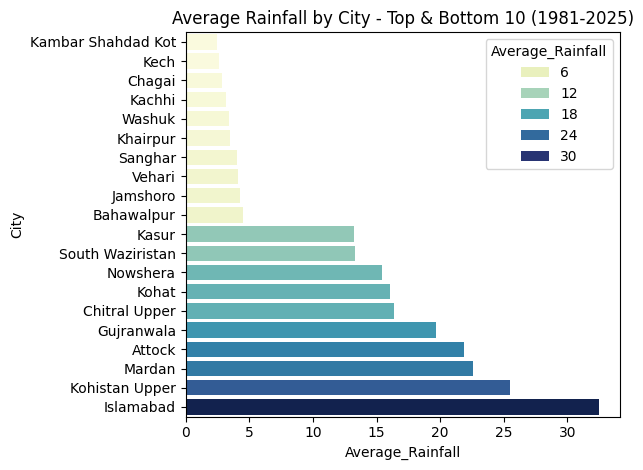

In [237]:
sns.barplot(y="City",x="Average_Rainfall",data=combinedCities,hue="Average_Rainfall",palette="YlGnBu")
plt.title('Average Rainfall by City - Top & Bottom 10 (1981-2025)')
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\top&bottomrainfallcities.png',
    dpi=300,     
    bbox_inches='tight'
)
print("✅ barchart saved!")
plt.show()
plt.close()

### Temperature by city comparsion

In [238]:
averageTemperaturebycities = weather_df.groupby('city').agg(
    Average_Temperature = ("temp_max","mean")
)
print(averageTemperaturebycities)

            Average_Temperature
city                           
Abbottabad            21.791687
Bahawalpur            32.253715
Faisalabad            30.719936
Gilgit                17.247188
Gwadar                28.830053
Hyderabad             34.089121
Islamabad             26.765923
Karachi               30.085536
Lahore                29.740054
Multan                31.624192
Quetta                23.410528
Rawalpindi            27.197342
Sialkot               28.428930
Skardu                10.737797
Sukkur                33.870160


In [239]:
averageTemperaturebycities.sort_values(by="Average_Temperature",inplace=True)
print(averageTemperaturebycities)

            Average_Temperature
city                           
Skardu                10.737797
Gilgit                17.247188
Abbottabad            21.791687
Quetta                23.410528
Islamabad             26.765923
Rawalpindi            27.197342
Sialkot               28.428930
Gwadar                28.830053
Lahore                29.740054
Karachi               30.085536
Faisalabad            30.719936
Multan                31.624192
Bahawalpur            32.253715
Sukkur                33.870160
Hyderabad             34.089121


✅ barchart saved!


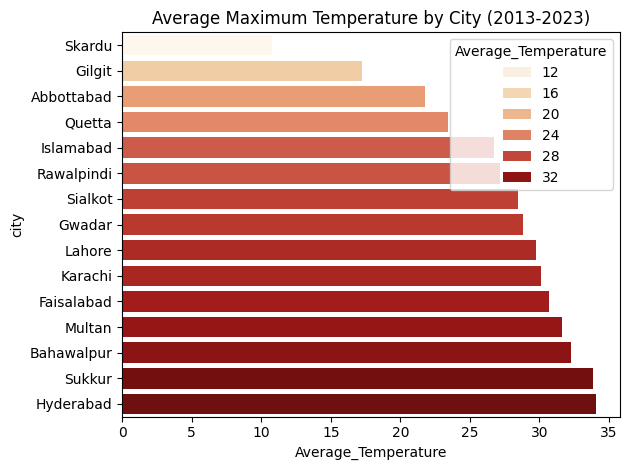

In [240]:
sns.barplot(y="city",x="Average_Temperature",data=averageTemperaturebycities,hue="Average_Temperature" , palette="OrRd")
plt.title('Average Maximum Temperature by City (2013-2023)')
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\averageTemByCities.png',
    dpi=300,     
    bbox_inches='tight'
)
print("✅ barchart saved!")
plt.show()
plt.close()

### Monthly temperature pattern

In [241]:
averageTemperaturebymonths = weather_df.groupby("city").agg(
    Average_Temperature = ("temp_max","mean")
)
print(averageTemperaturebymonths)

            Average_Temperature
city                           
Abbottabad            21.791687
Bahawalpur            32.253715
Faisalabad            30.719936
Gilgit                17.247188
Gwadar                28.830053
Hyderabad             34.089121
Islamabad             26.765923
Karachi               30.085536
Lahore                29.740054
Multan                31.624192
Quetta                23.410528
Rawalpindi            27.197342
Sialkot               28.428930
Skardu                10.737797
Sukkur                33.870160


In [242]:
averageTemperaturebymonths.sort_values(by="Average_Temperature",ascending=False,inplace=True)

In [243]:
top5HottestCites = averageTemperaturebymonths.head(5)
print(top5HottestCites)

            Average_Temperature
city                           
Hyderabad             34.089121
Sukkur                33.870160
Bahawalpur            32.253715
Multan                31.624192
Faisalabad            30.719936


In [244]:
top5_cities_list = top5HottestCites.index.tolist()
print(f"\nTop 5 cities: {top5_cities_list}")


Top 5 cities: ['Hyderabad', 'Sukkur', 'Bahawalpur', 'Multan', 'Faisalabad']


In [245]:
monthly_data_top5 = weather_df[weather_df['city'].isin(top5_cities_list)]

monthly_avg_top5 = monthly_data_top5.groupby(["city", "month"]).agg(
    Average_Temperature = ("temp_max", "mean")
).reset_index()

print("\nMonthly data for top 5 cities:")
print(monthly_avg_top5)


Monthly data for top 5 cities:
          city      month  Average_Temperature
0   Bahawalpur      April            36.540350
1   Bahawalpur     August            37.354721
2   Bahawalpur   December            22.057278
3   Bahawalpur   February            24.435133
4   Bahawalpur    January            19.974237
5   Bahawalpur       July            38.374721
6   Bahawalpur       June            40.673350
7   Bahawalpur      March            29.434560
8   Bahawalpur        May            40.108108
9   Bahawalpur   November            27.285350
10  Bahawalpur    October            33.835850
11  Bahawalpur  September            36.690350
12  Faisalabad      April            34.475883
13  Faisalabad     August            36.460953
14  Faisalabad   December            21.062043
15  Faisalabad   February            23.029246
16  Faisalabad    January            18.506114
17  Faisalabad       July            36.071437
18  Faisalabad       June            39.271717
19  Faisalabad      March   

In [246]:
monthly_avg_top5['month_num'] = monthly_avg_top5['month'].map(month_mapping)
monthly_avg_top5 = monthly_avg_top5.sort_values(['city', 'month_num'])
print(monthly_avg_top5)

          city      month  Average_Temperature  month_num
4   Bahawalpur    January            19.974237          1
3   Bahawalpur   February            24.435133          2
7   Bahawalpur      March            29.434560          3
0   Bahawalpur      April            36.540350          4
8   Bahawalpur        May            40.108108          5
6   Bahawalpur       June            40.673350          6
5   Bahawalpur       July            38.374721          7
1   Bahawalpur     August            37.354721          8
11  Bahawalpur  September            36.690350          9
10  Bahawalpur    October            33.835850         10
9   Bahawalpur   November            27.285350         11
2   Bahawalpur   December            22.057278         12
16  Faisalabad    January            18.506114          1
15  Faisalabad   February            23.029246          2
19  Faisalabad      March            27.339179          3
12  Faisalabad      April            34.475883          4
20  Faisalabad

✅ Monthly temperature pattern chart saved!


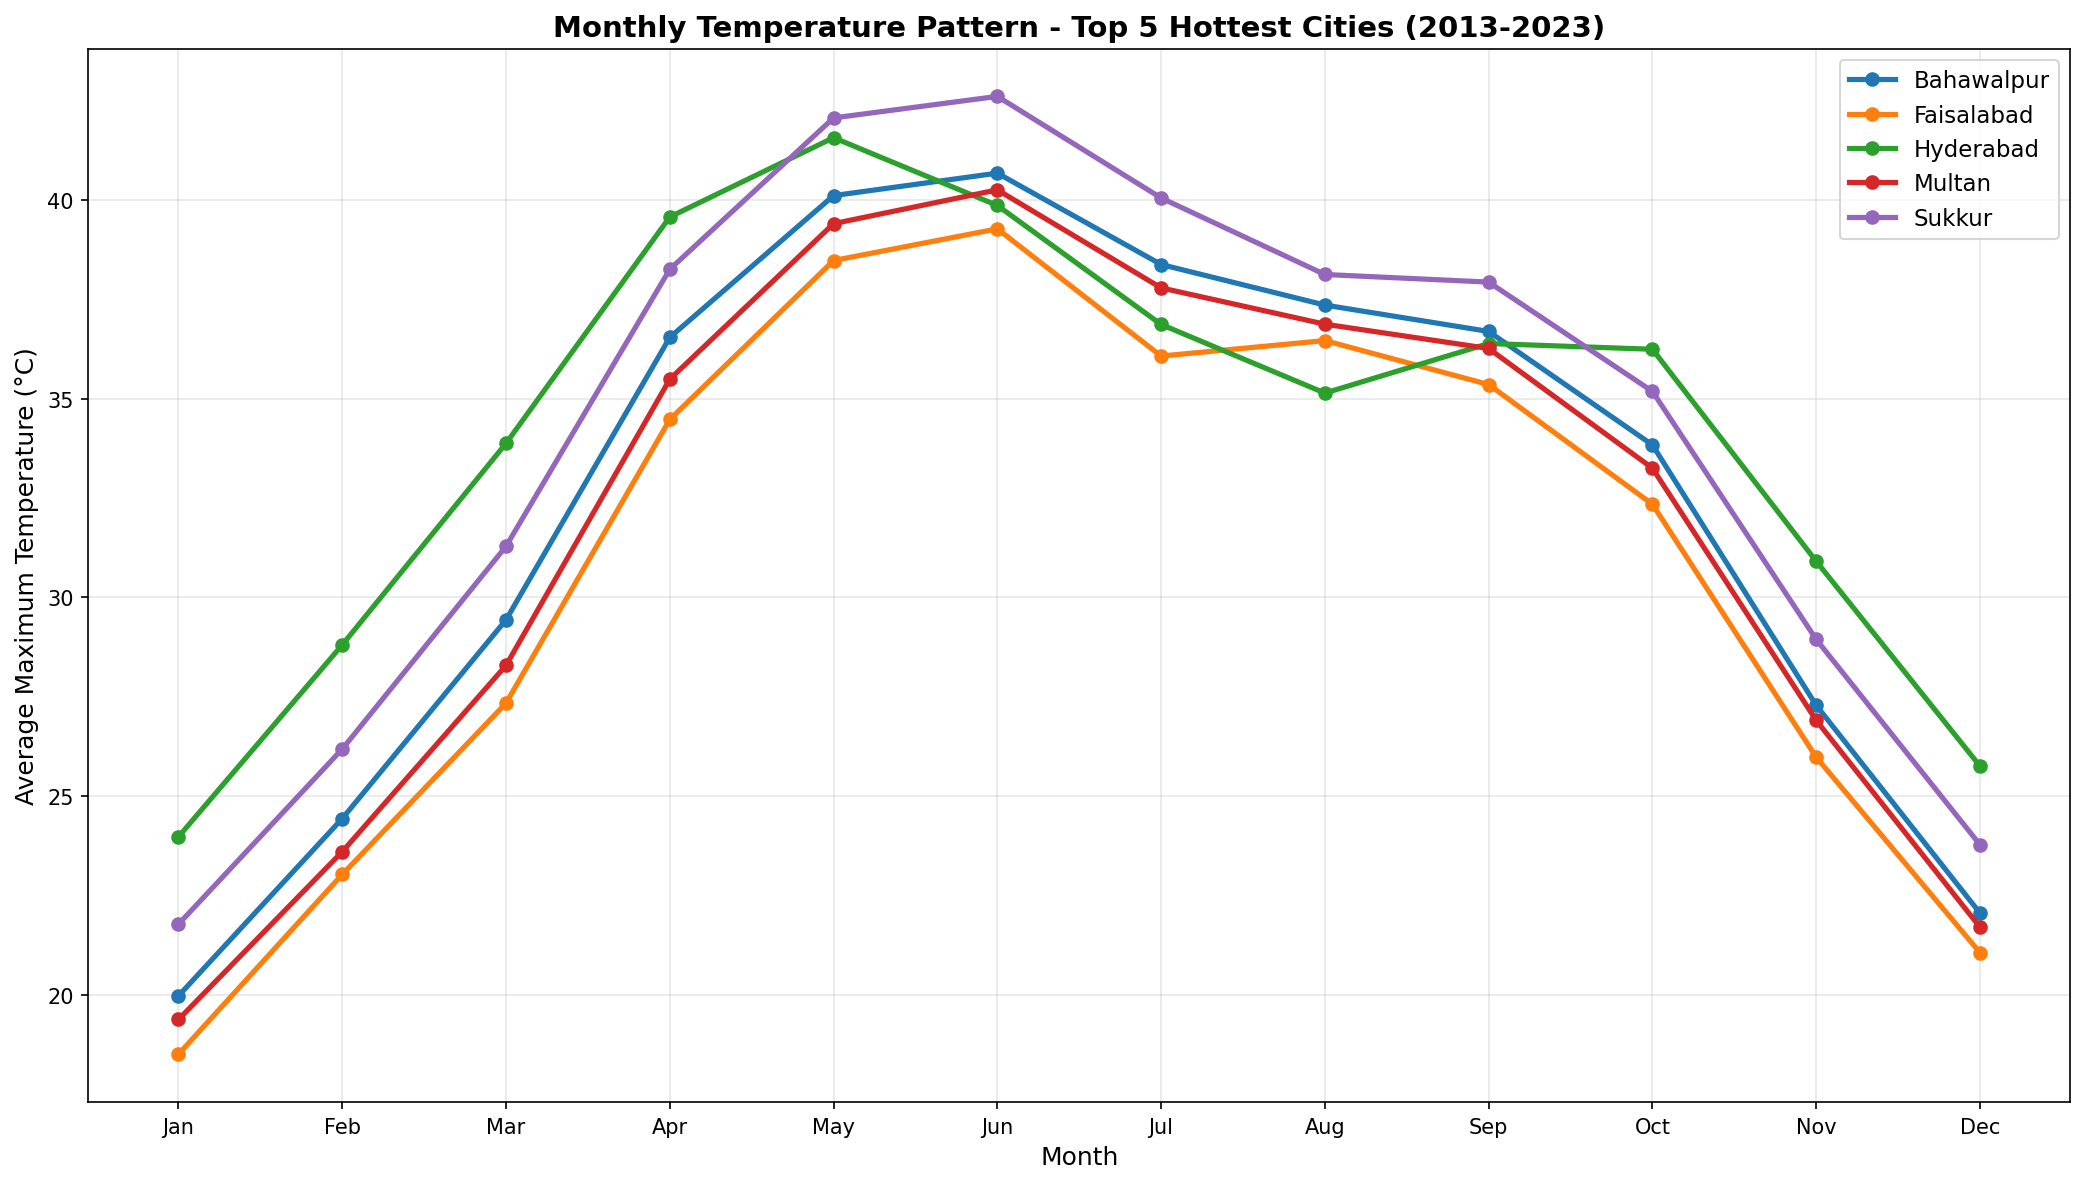

In [247]:
plt.figure(figsize=(14, 8), dpi=150)

for city in monthly_avg_top5['city'].unique():
    city_data = monthly_avg_top5[monthly_avg_top5['city'] == city]
    plt.plot(
        city_data['month_num'],
        city_data['Average_Temperature'],
        marker='o',
        label=city,
        linewidth=2.5,
        markersize=6
    )

plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Maximum Temperature (°C)', fontsize=12)
plt.title('Monthly Temperature Pattern - Top 5 Hottest Cities (2013-2023)', 
          fontsize=14, fontweight='bold')

plt.xticks(range(1, 13), 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.grid(True, alpha=0.3)

plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\monthly_temperature_pattern.png',
    dpi=300,
    bbox_inches='tight'
)
print("✅ Monthly temperature pattern chart saved!")
plt.show()

### Temperature Distribution (By city)

In [248]:

hyderabad_temps = weather_df[weather_df['city'] == 'Hyderabad']['temp_max']
skardu_temps = weather_df[weather_df['city'] == 'Skardu']['temp_max']
lahore_temps = weather_df[weather_df['city'] == 'Lahore']['temp_max']

print(f"Hyderabad temps: {len(hyderabad_temps)} values")
print(f"Skardu temps: {len(skardu_temps)} values")
print(f"Lahore temps: {len(lahore_temps)} values")

print(f"\nHyderabad min: {hyderabad_temps.min()}, max: {hyderabad_temps.max()}")
print(f"Skardu min: {skardu_temps.min()}, max: {skardu_temps.max()}")
print(f"Lahore min: {lahore_temps.min()}, max: {lahore_temps.max()}")

Hyderabad temps: 3653 values
Skardu temps: 3653 values
Lahore temps: 3653 values

Hyderabad min: 15.65, max: 47.95
Skardu min: -16.9775, max: 34.8055
Lahore min: 10.3, max: 46.3


✅ KDE plot saved!


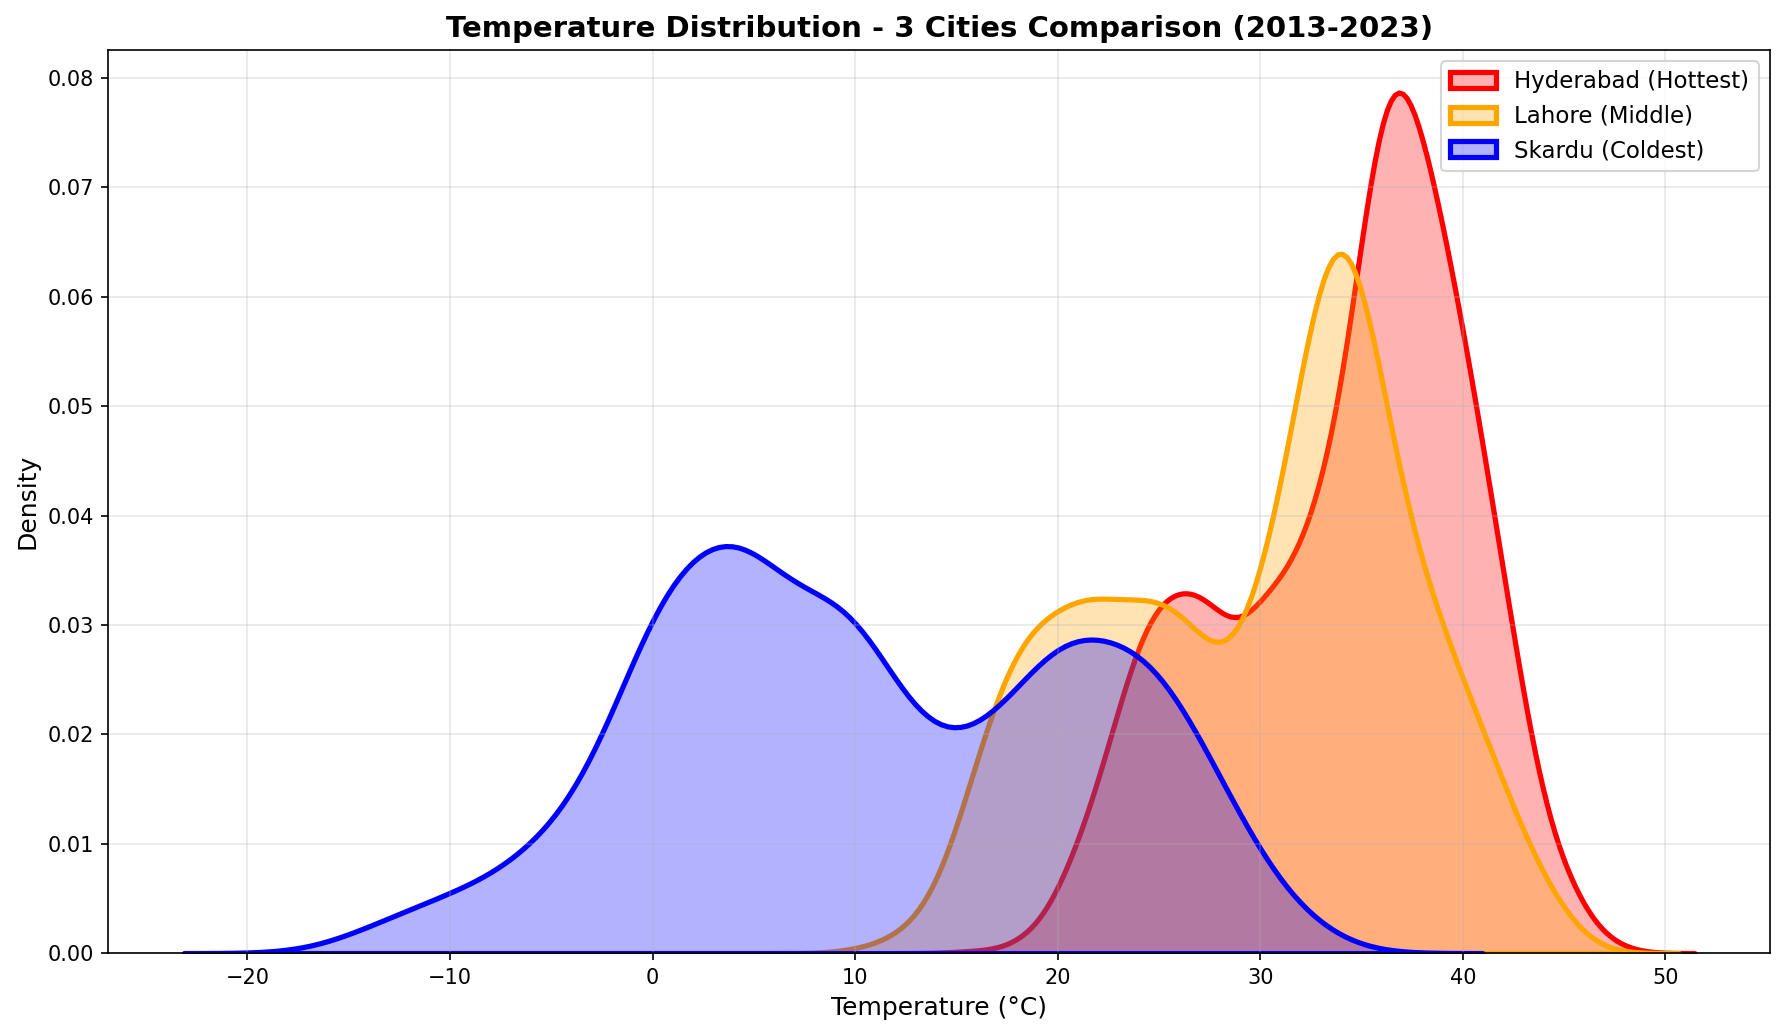

In [249]:
plt.figure(figsize=(12, 7), dpi=150)
sns.kdeplot(
    data=hyderabad_temps,
    label='Hyderabad (Hottest)',
    color='red',
    linewidth=2.5,
    fill=True,
    alpha=0.3
)
sns.kdeplot(
    data=lahore_temps,
    label='Lahore (Middle)',
    color='orange',
    linewidth=2.5,
    fill=True,
    alpha=0.3
)
sns.kdeplot(
    data=skardu_temps,
    label='Skardu (Coldest)',
    color='blue',
    linewidth=2.5,
    fill=True,
    alpha=0.3
)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Temperature Distribution - 3 Cities Comparison (2013-2023)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.legend(fontsize=11, loc='best')
plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\temperature_distribution_kde.png',
    dpi=300,
    bbox_inches='tight'
)

print("✅ KDE plot saved!")
plt.show()
plt.close()

### Provincal Climate Profile

In [250]:
average_rainfall_per_province = rainfall_df.groupby("Province").agg(
    Average_Rainfall = ("Rainfall - (MM)","mean")
).reset_index()
print(average_rainfall_per_province)

             Province  Average_Rainfall
0         Balochistan          4.038214
1           Islamabad         32.504673
2  Khyber Pakhtunkhwa         16.087695
3              Punjab         10.589339
4               Sindh          4.324195


In [251]:
city_to_province = {
    'Rawalpindi': 'Punjab',
    'Islamabad': 'Islamabad',
    'Abbottabad': 'Khyber Pakhtunkhwa',
    'Gilgit': 'Gilgit-Baltistan',
    'Skardu': 'Gilgit-Baltistan',
    'Lahore': 'Punjab',
    'Faisalabad': 'Punjab',
    'Sialkot': 'Punjab',
    'Multan': 'Punjab',
    'Bahawalpur': 'Punjab',
    'Karachi': 'Sindh',
    'Hyderabad': 'Sindh',
    'Sukkur': 'Sindh',
    'Quetta': 'Balochistan',
    'Gwadar': 'Balochistan'
}
weather_df['province'] = weather_df['city'].map(city_to_province)
print(weather_df[['city', 'province']].tail(1000))
print(f"\nProvinces in weather data: {weather_df['province'].unique()}")

         city     province
53795  Gwadar  Balochistan
53796  Gwadar  Balochistan
53797  Gwadar  Balochistan
53798  Gwadar  Balochistan
53799  Gwadar  Balochistan
...       ...          ...
54790  Gwadar  Balochistan
54791  Gwadar  Balochistan
54792  Gwadar  Balochistan
54793  Gwadar  Balochistan
54794  Gwadar  Balochistan

[1000 rows x 2 columns]

Provinces in weather data: ['Punjab' 'Islamabad' 'Khyber Pakhtunkhwa' 'Gilgit-Baltistan' 'Sindh'
 'Balochistan']


In [252]:
average_temp_per_province = weather_df.groupby("province").agg(
    Average_Temperature = ("temp_max","mean")
).reset_index()
print(average_temp_per_province)

             province  Average_Temperature
0         Balochistan            26.120291
1    Gilgit-Baltistan            13.992493
2           Islamabad            26.765923
3  Khyber Pakhtunkhwa            21.791687
4              Punjab            29.994028
5               Sindh            32.681606


In [253]:

print("Table 1 - Rainfall by Province:")
print(average_rainfall_per_province)
print(average_rainfall_per_province.columns)

print("\n" + "="*50 + "\n")


print("Table 2 - Temperature by Province:")
print(average_temp_per_province)
print(average_temp_per_province.columns)

Table 1 - Rainfall by Province:
             Province  Average_Rainfall
0         Balochistan          4.038214
1           Islamabad         32.504673
2  Khyber Pakhtunkhwa         16.087695
3              Punjab         10.589339
4               Sindh          4.324195
Index(['Province', 'Average_Rainfall'], dtype='object')


Table 2 - Temperature by Province:
             province  Average_Temperature
0         Balochistan            26.120291
1    Gilgit-Baltistan            13.992493
2           Islamabad            26.765923
3  Khyber Pakhtunkhwa            21.791687
4              Punjab            29.994028
5               Sindh            32.681606
Index(['province', 'Average_Temperature'], dtype='object')


In [256]:
average_rainfall_per_province['Province'] = average_rainfall_per_province['Province'].str.lower()
average_temp_per_province['province'] = average_temp_per_province['province'].str.lower()
average_rainfall_per_province.columns = ['province', 'Average_Rainfall']
average_temp_per_province.columns = ['province', 'Average_Temperature']

print("Rainfall provinces:")
print(average_rainfall_per_province)

print("\nTemperature provinces:")
print(average_temp_per_province)

province_profile = average_rainfall_per_province.merge(
    average_temp_per_province,
    on='province',
    how='outer'
)

print("\nCombined Table - Provincial Climate Profile:")
print(province_profile)
print(f"\nShape: {province_profile.shape}")

Rainfall provinces:
             province  Average_Rainfall
0         balochistan          4.038214
1           islamabad         32.504673
2  khyber pakhtunkhwa         16.087695
3              punjab         10.589339
4               sindh          4.324195

Temperature provinces:
             province  Average_Temperature
0         balochistan            26.120291
1    gilgit-baltistan            13.992493
2           islamabad            26.765923
3  khyber pakhtunkhwa            21.791687
4              punjab            29.994028
5               sindh            32.681606

Combined Table - Provincial Climate Profile:
             province  Average_Rainfall  Average_Temperature
0         balochistan          4.038214            26.120291
1    gilgit-baltistan               NaN            13.992493
2           islamabad         32.504673            26.765923
3  khyber pakhtunkhwa         16.087695            21.791687
4              punjab         10.589339            29.994028
5  

Heatmap data:
                    Average_Rainfall  Average_Temperature
province                                                 
balochistan                 4.038214            26.120291
gilgit-baltistan                 NaN            13.992493
islamabad                  32.504673            26.765923
khyber pakhtunkhwa         16.087695            21.791687
punjab                     10.589339            29.994028
sindh                       4.324195            32.681606
✅ Provincial climate profile heatmap saved!


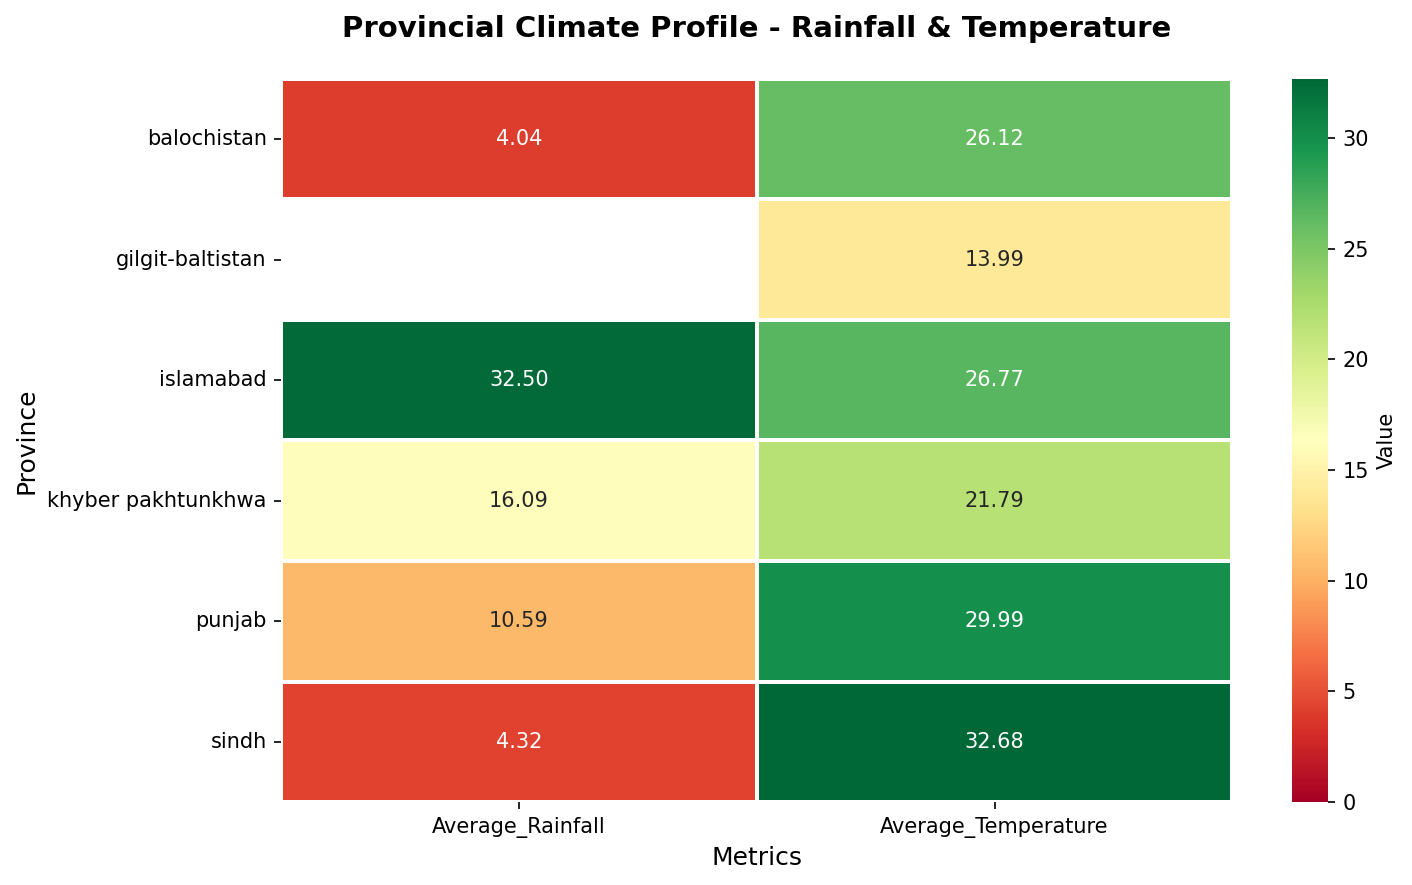

In [257]:
heatmap_data = province_profile.set_index('province')

print("Heatmap data:")
print(heatmap_data)

plt.figure(figsize=(10, 6), dpi=150)

sns.heatmap(
    heatmap_data,
    annot=True,          
    fmt='.2f',           
    cmap='RdYlGn',        
    cbar_kws={'label': 'Value'},
    linewidths=1,        
    linecolor='white',
    vmin=0,              
    vmax=max(heatmap_data.max()) 
)

plt.title('Provincial Climate Profile - Rainfall & Temperature', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Province', fontsize=12)

plt.tight_layout()
plt.savefig(
    r'D:\CS 6th sem books\Summer2026\Weather_Analysis\visualizations\provincial_climate_profile_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

print("✅ Provincial climate profile heatmap saved!")
plt.show()
plt.close()